<a target="_blank" href="https://github.com/jgromero/dasoc-ap/blob/main/conspiraciones/finetuning-conspiraciones.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
</a>

# Clasificación usando un modelo preentrenado


Instalar dependencias e importar. Utilizaremos [`PyTorch`](https://pytorch.org), ya que desde su versión 5.2 [`Transformers`](https://pypi.org/project/transformers/) no soporta Keras.



In [1]:
!pip -q install transformers torch

import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

Descargar y particionar datos de ["Oppositional thinking analysis: Conspiracy theories vs critical thinking narratives"](https://pan.webis.de/clef24/pan24-web/oppositional-thinking-analysis.html).

In [ ]:
import gdown
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Descargar el archivo dataset.csv desde Google Drive
url = 'https://drive.google.com/uc?id=178ixCNZzdrueSH8FgufOXFPfkmAGMUxH'
output = 'dataset.csv'
gdown.download(url, output, quiet=False)

# Leer datos
data = pd.read_csv('dataset.csv')

# Hacer particiones de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(
    data['text'], data['category'],
    test_size=0.2,
    random_state=42
) # for training + test

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42
) # train + validation

# Codificar salidas de predicción
label_encoder = LabelEncoder()
y_train_numerical = label_encoder.fit_transform(y_train)
y_val_numerical = label_encoder.transform(y_val)
y_test_numerical = label_encoder.transform(y_test)

Downloading...
From: https://drive.google.com/uc?id=178ixCNZzdrueSH8FgufOXFPfkmAGMUxH
To: /content/dataset.csv
100%|██████████| 2.34M/2.34M [00:00<00:00, 153MB/s]


Cargar modelo. El modelo seleccionado para este ejemplo es [`distilbert-base-uncased`](https://huggingface.co/distilbert/distilbert-base-uncased), una versión compacta de [`BERT`](https://huggingface.co/docs/transformers/model_doc/bert).

In [3]:
checkpoint = 'distilbert-base-uncased'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=2
).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenizar datos de entrenamiento y validación.

In [4]:
max_len = 128

tokenizer = AutoTokenizer.from_pretrained(checkpoint)

# Datos de entrenamiento
enc = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=max_len,
    return_tensors="pt"
)

X_ids = enc["input_ids"]
X_mask = enc["attention_mask"]

y = torch.tensor(y_train_numerical, dtype=torch.long)

# Datos de validación
val_enc = tokenizer(
    X_val.tolist() ,
    truncation=True,
    padding=True,
    max_length=max_len,
    return_tensors="pt"
)

X_val_ids = val_enc["input_ids"]
X_val_mask = val_enc["attention_mask"]

y_val = torch.tensor(y_val_numerical, dtype=torch.long)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Función auxiliar para visualizar las métricas del entrenamiento.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.plot(history["accuracy"], label="train")
    ax1.plot(history["val_accuracy"], label="val")
    ax1.set_title("Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.legend(loc="upper left")

    ax2.plot(history["loss"], label="train")
    ax2.plot(history["val_loss"], label="val")
    ax2.set_title("Loss")
    ax2.set_xlabel("Epoch")
    ax2.legend(loc="upper left")

    plt.tight_layout()
    plt.show()

Función para entrenamiento de modelos.

In [8]:
def train_model(
    model,
    optimizer,
    X_train_ids, X_train_mask, y_train,
    X_val_ids, X_val_mask, y_val,
    device,
    epochs=3,
    batch_size=8
):
    history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}

    n = X_train_ids.size(0)

    for epoch in range(epochs):
        # ---- TRAIN (mini-batches) ----
        model.train()
        perm = torch.randperm(n)

        total_loss = 0.0
        correct = 0
        total = 0

        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]

            input_ids = X_train_ids[idx].to(device)
            attention_mask = X_train_mask[idx].to(device)
            labels = y_train[idx].to(device)

            optimizer.zero_grad()
            out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = out.loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels.size(0)
            preds = out.logits.argmax(dim=-1).detach().cpu()
            correct += (preds == labels.cpu()).sum().item()
            total += labels.size(0)

        train_loss = total_loss / total
        train_acc = correct / total

        # ---- VAL (mini-batches, no grad) ----
        model.eval()
        vn = X_val_ids.size(0)
        v_total_loss = 0.0
        v_correct = 0
        v_total = 0

        with torch.no_grad():
            for i in range(0, vn, batch_size):
                input_ids = X_val_ids[i:i+batch_size].to(device)
                attention_mask = X_val_mask[i:i+batch_size].to(device)
                labels = y_val[i:i+batch_size].to(device)

                vout = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                vloss = vout.loss.item()

                v_total_loss += vloss * labels.size(0)
                vpreds = vout.logits.argmax(dim=-1).cpu()
                v_correct += (vpreds == labels.cpu()).sum().item()
                v_total += labels.size(0)

        val_loss = v_total_loss / v_total
        val_acc = v_correct / v_total

        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        print(
            f"Epoch {epoch+1} | loss={train_loss:.4f} acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

    return history

Entrenar solamente parte de clasificación.

Epoch 1 | loss=0.4036 acc=0.8187 | val_loss=0.5048 val_acc=0.7359
Epoch 2 | loss=0.3931 acc=0.8207 | val_loss=0.3444 val_acc=0.8328
Epoch 3 | loss=0.3839 acc=0.8281 | val_loss=0.3376 val_acc=0.8516


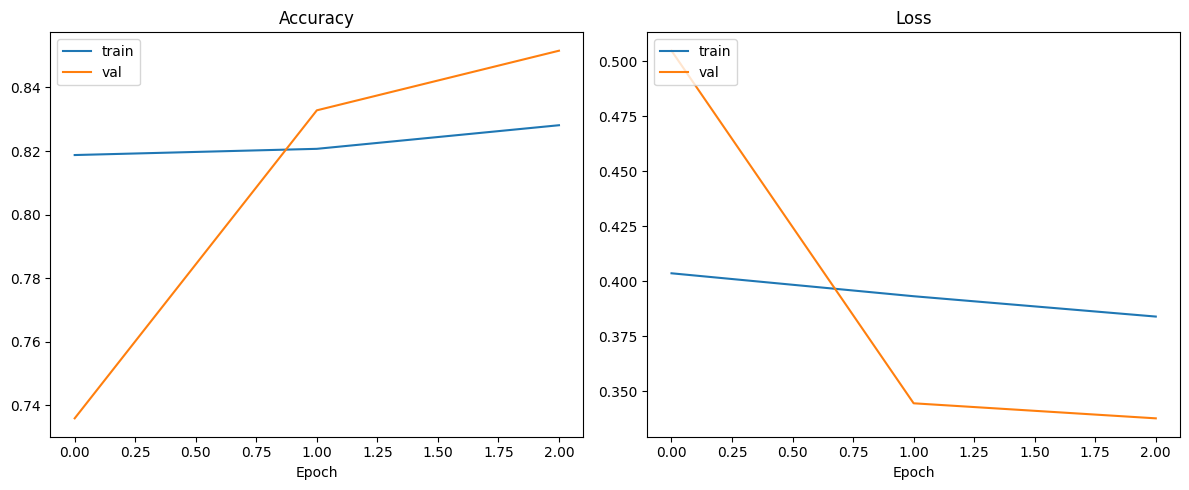

In [10]:
# Congelar todos los pesos del codificador DistilBERT
# La cabeza clasificadora permanece entrenable por defecto
for p in model.distilbert.parameters():
    p.requires_grad = False

# Definir optimizador sobre pesos entrenables
optimizer1 = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-4)

# Realizar entrenamiento
hist1 = train_model(
    model, optimizer1,
    X_ids, X_mask, y,
    X_val_ids, X_val_mask, y_val,
    device,
    epochs=3,
    batch_size=8
)

# Visualizar
plot_training_history(hist1)

Entrenar también las últimas `N` capas.

Epoch 1 | loss=0.3543 acc=0.8391 | val_loss=0.2869 val_acc=0.8594
Epoch 2 | loss=0.2708 acc=0.8840 | val_loss=0.2603 val_acc=0.8906
Epoch 3 | loss=0.2058 acc=0.9168 | val_loss=0.2597 val_acc=0.8906


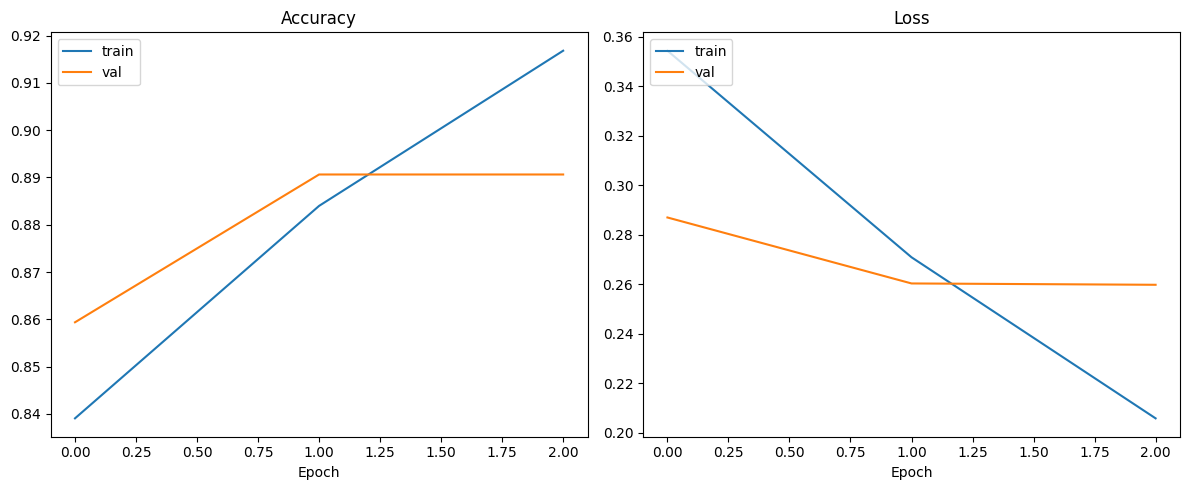

In [11]:
N = 2  # Últimos dos bloques (de 6)

# Congelar el 'encoder'
for p in model.distilbert.parameters():
    p.requires_grad = False

# Descongelar las últimas N capas de los bloques 'transformer'
for block in model.distilbert.transformer.layer[-N:]:
    for p in block.parameters():
        p.requires_grad = True

# Asegurar que la cabeza clasidifcaora permanece entrenable
for p in model.pre_classifier.parameters():
    p.requires_grad = True
for p in model.classifier.parameters():
    p.requires_grad = True

# Definir optimizador sobre pesos entrenables
optimizer2 = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)

# Realizar entrenamiento
hist2 = train_model(
    model, optimizer2,
    X_ids, X_mask, y,
    X_val_ids, X_val_mask, y_val,
    device,
    epochs=3,
    batch_size=8
)

# Visualizar
plot_training_history(hist2)

# Ejercicio (no evaluable)
Ajusta el entrenamiento de los modelos y compara los resultados utilizando la partición de test.